In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

In [8]:
stations = ['10100000', '13050000', '14100000']

#### Importação e tratamento de dados OBS e PREVISTOS

In [2]:
pasta = Path(r"C:/Users/emily/Documents/Dados_previsao_operacao/dados_previsoes_passadas/operacao_2026_03_23")

def carregar_series_completas():
    dados = {}
    
    for arquivo in pasta.glob("*_complete_date_inference.csv"):
        
        estacao = arquivo.name.split("_")[0]
        
        try:
            df = pd.read_csv(
                arquivo,
                parse_dates=['date']
            )
        except Exception as e:
            print(f"Erro ao ler {arquivo.name}: {e}")
            continue
        
        if df.empty:
            print(f"Aviso: {arquivo.name} está vazio.")
            continue
        
        df = df.sort_values('date').reset_index(drop=True)
        
        dados[estacao] = df
        
        print(f"Estação {estacao}: {len(df)} registros carregados.")
    
    return dados

In [3]:
dados_historicos = carregar_series_completas()

Estação 10100000: 36 registros carregados.
Estação 14100000: 36 registros carregados.


In [16]:
caminho = Path(r"C:\Users\emily\Documents\GitHub\Mini-curso-GitHub-Leo\outputs\experiments\exp_003_Improve_model_performance_adjustment_freerun_gatemax\predictions_operational\raw\prediction_2026_03_17.csv")

def carregar_previsoes():
    
    df = pd.read_csv(
        caminho,
        parse_dates=['date']
    )
    
    # Garante ordenação
    df = df.sort_values('date').reset_index(drop=True)
    
    print(f"Previsões carregadas: {len(df)} dias")
    print(df.head())
    
    return df

In [17]:
def organizar_previsoes_por_estacao(df_previsoes):
    """
    Converte:
    date | Q_pred_10100000 | Q_pred_14100000
    
    → dict:
    {
        '10100000': df(date, Q_pred),
        ...
    }
    """
    
    previsoes_dict = {}
    
    for col in df_previsoes.columns:
        if col.startswith("Q_pred_"):
            
            estacao = col.replace("Q_pred_", "")
            
            df_est = df_previsoes[['date', col]].copy()
            df_est.rename(columns={col: 'Q_pred'}, inplace=True)
            
            previsoes_dict[estacao] = df_est
    
    return previsoes_dict

In [18]:
# 1. Históricos
dados_historicos = carregar_series_completas()

# 2. Previsões
df_previsoes = carregar_previsoes()

# 3. Organizar previsões
previsoes_dict = organizar_previsoes_por_estacao(df_previsoes)

Estação 10100000: 36 registros carregados.
Estação 14100000: 36 registros carregados.
Previsões carregadas: 15 dias
        date  Q_pred_10100000  Q_pred_13150000  Q_pred_14100000
0 2026-03-17        55349.890        98556.945       103434.164
1 2026-03-18        55218.560        98338.600       103077.875
2 2026-03-19        55055.242        98062.730       102699.650
3 2026-03-20        54867.094        97742.914       102301.090
4 2026-03-21        54651.195        97381.440       101875.620


### Plotagem dos Dados

In [19]:
def plot_operacional(dados_historicos, previsoes_dict, stations):
    """
    Plota observado vs previsto para cada estação (um gráfico por estação).
    
    Args:
        dados_historicos: dict {estacao: df(date, mean_Q, mean_P)}
        previsoes_dict: dict {estacao: df(date, Q_pred)}
        stations: lista de estações
    """
    
    for st in stations:
        
        if st not in dados_historicos:
            print(f"Estação {st} sem dados históricos.")
            continue
        
        if st not in previsoes_dict:
            print(f"Estação {st} sem previsão.")
            continue
        
        df_obs = dados_historicos[st].copy()
        df_pred = previsoes_dict[st].copy()
        
        # Garantir datetime
        df_obs['date'] = pd.to_datetime(df_obs['date'])
        df_pred['date'] = pd.to_datetime(df_pred['date'])
        
        # Ordenar
        df_obs = df_obs.sort_values('date')
        df_pred = df_pred.sort_values('date')
        
        # Data inicial da previsão
        forecast_start = df_pred['date'].min()
        
        # ==========================
        # PLOT
        # ==========================
        plt.figure(figsize=(14, 5))
        
        # Observado (toda série)
        plt.plot(
            df_obs['date'],
            df_obs['mean_Q'],
            label='Observado',
            color='black',
            linewidth=2
        )
        
        # Previsto (toda série)
        plt.plot(
            df_pred['date'],
            df_pred['Q_pred'],
            label='Previsto',
            color='royalblue',
            linestyle='--',
            linewidth=2
        )
        
        # Linha de início da previsão
        plt.axvline(
            forecast_start,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label='Início da previsão'
        )
        
        # ==========================
        # FORMATAÇÃO
        # ==========================
        plt.title(
            f'Estação {st} — Observado vs Previsão',
            fontsize=13,
            fontweight='bold'
        )
        
        plt.xlabel('Data')
        plt.ylabel('Vazão (m³/s)')
        plt.grid(True, alpha=0.3)
        
        # Formatação de datas
        ax = plt.gca()
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.xticks(rotation=45)
        
        plt.legend()
        plt.tight_layout()
        plt.show()

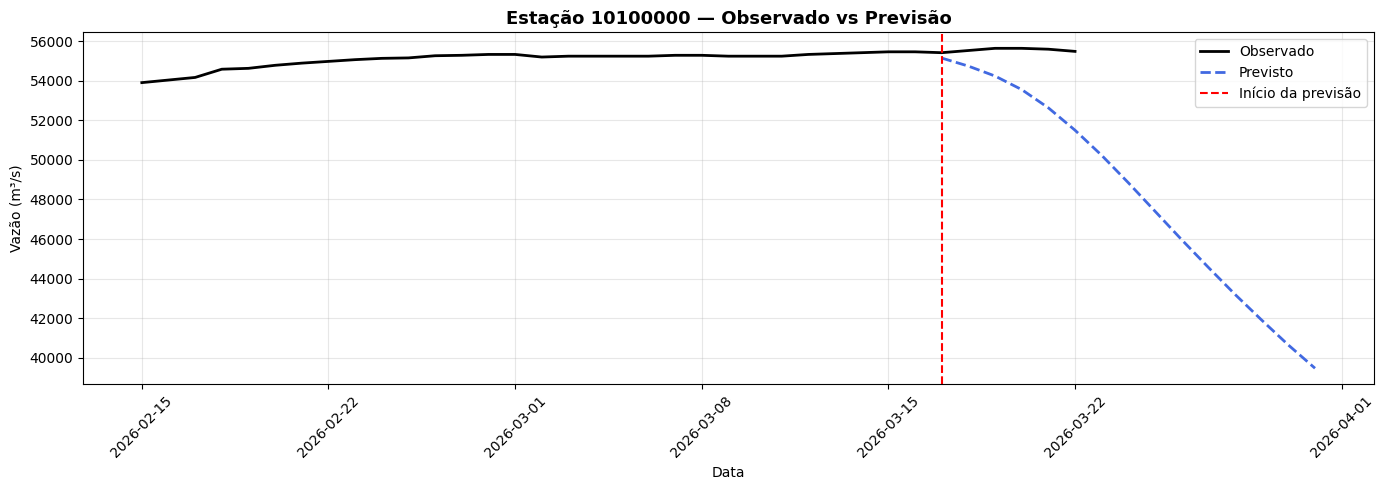

Estação 13050000 sem dados históricos.


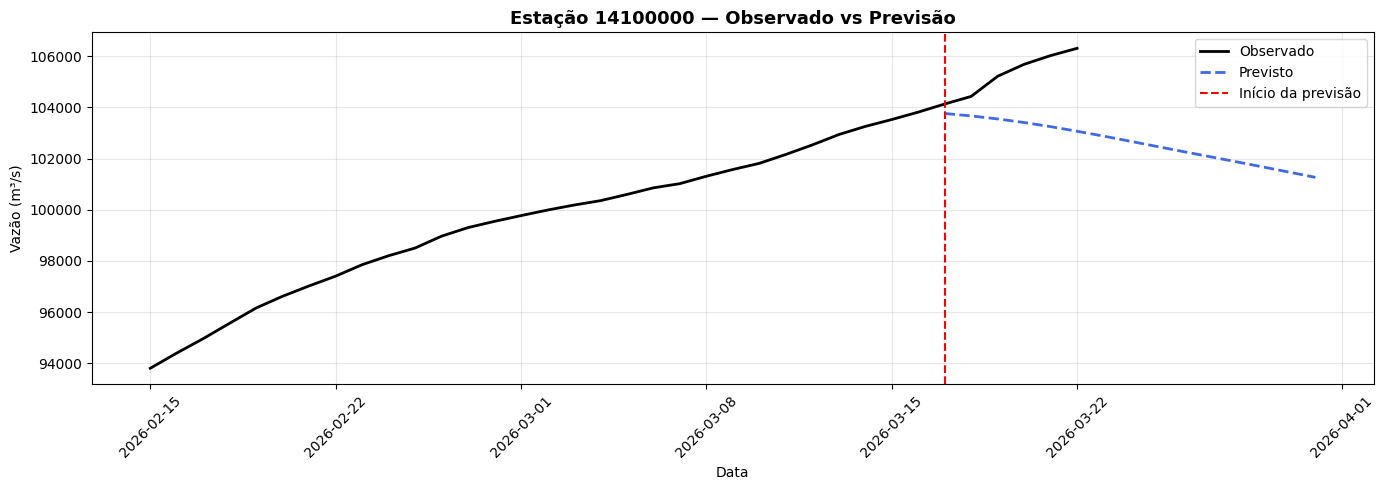

In [16]:
plot_operacional(dados_historicos, previsoes_dict, stations)

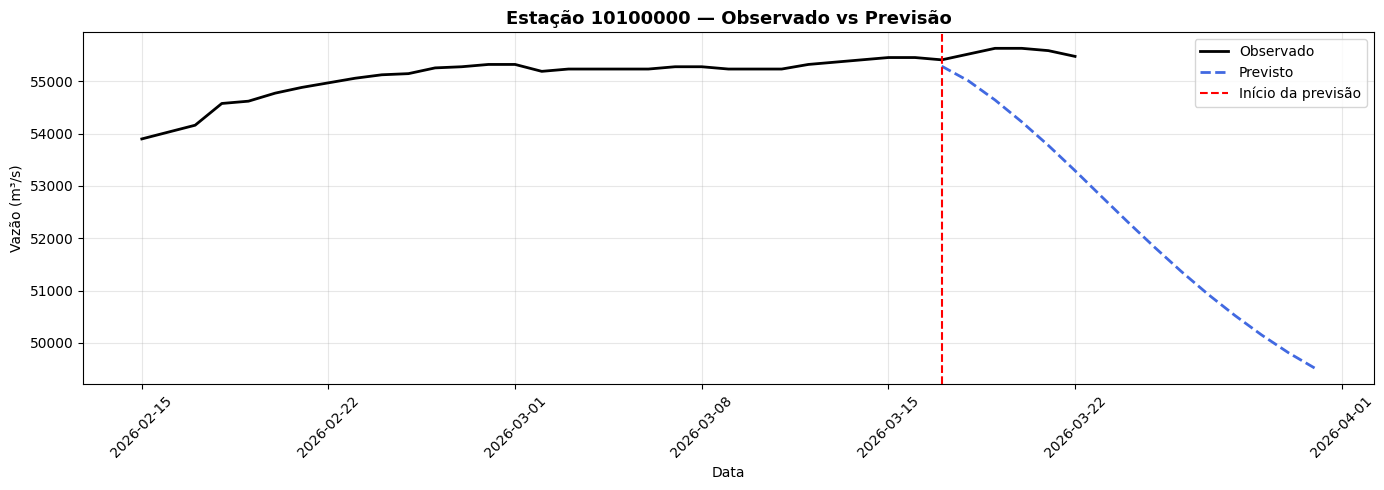

Estação 13050000 sem dados históricos.


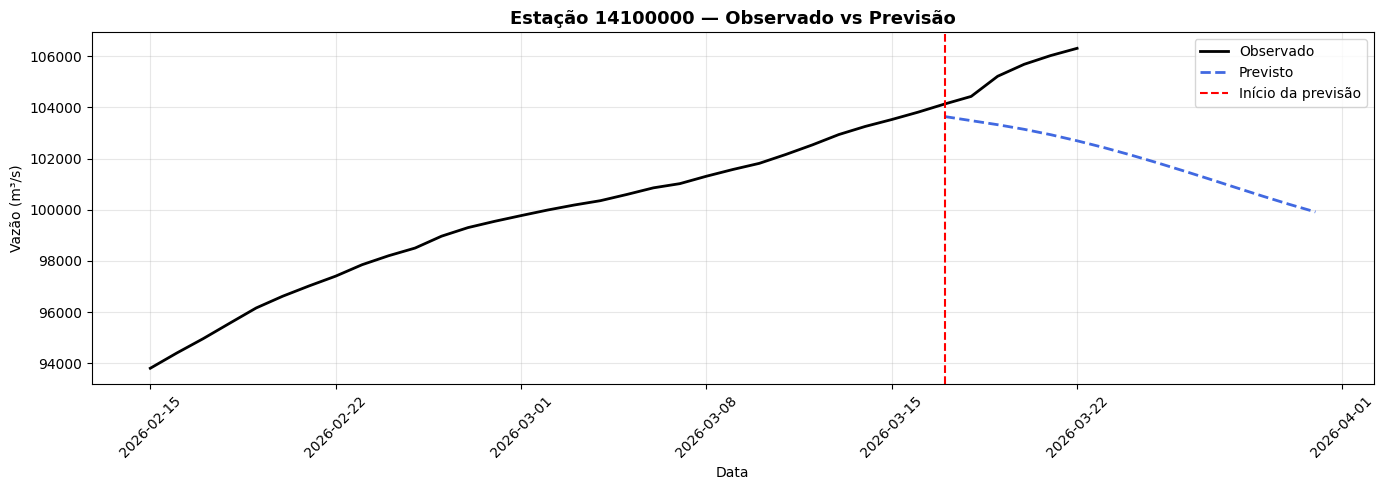

In [10]:
plot_operacional(dados_historicos, previsoes_dict, stations)

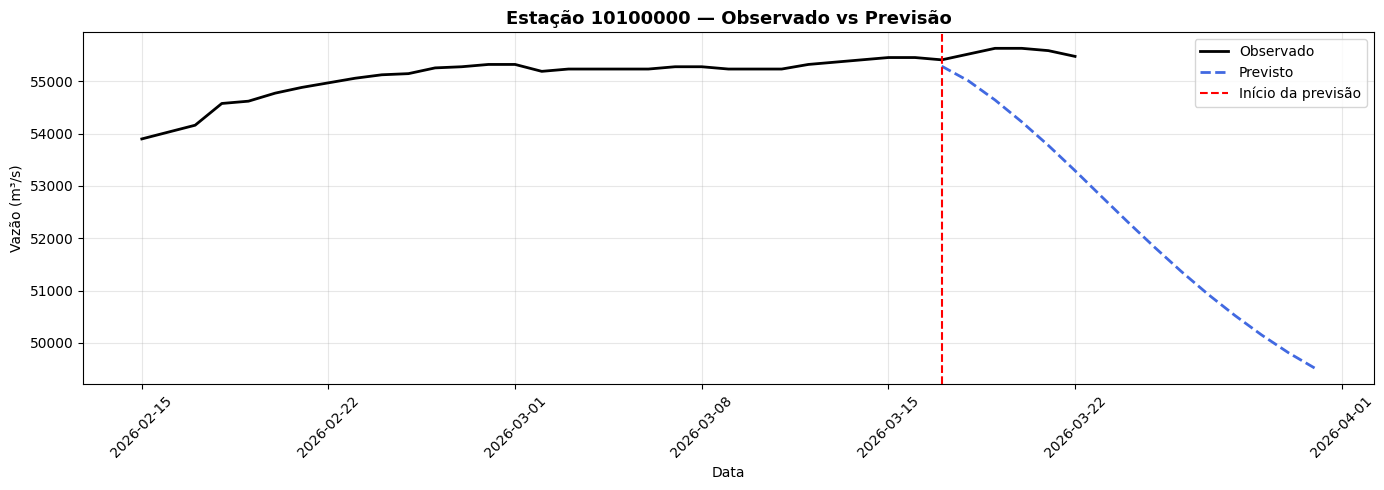

Estação 13050000 sem dados históricos.


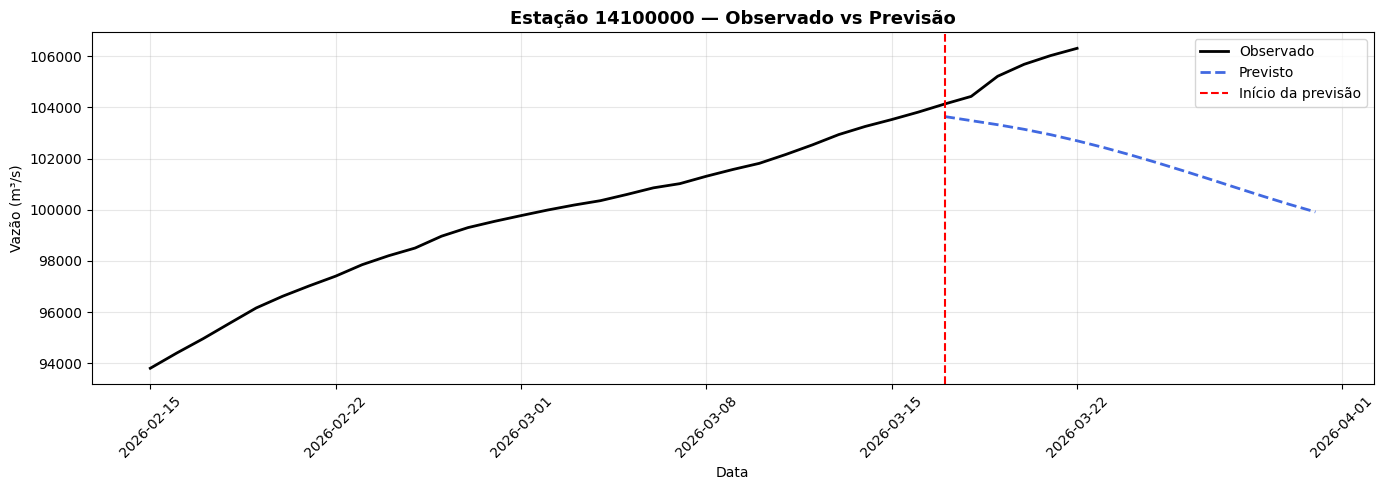

In [11]:
plot_operacional(dados_historicos, previsoes_dict, stations)

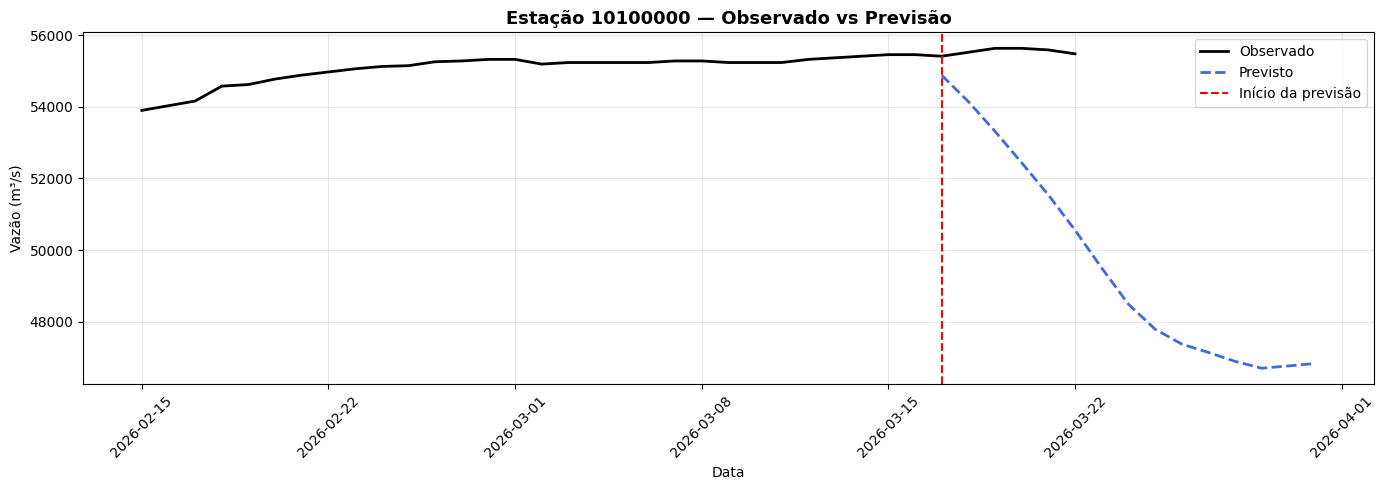

Estação 13050000 sem dados históricos.


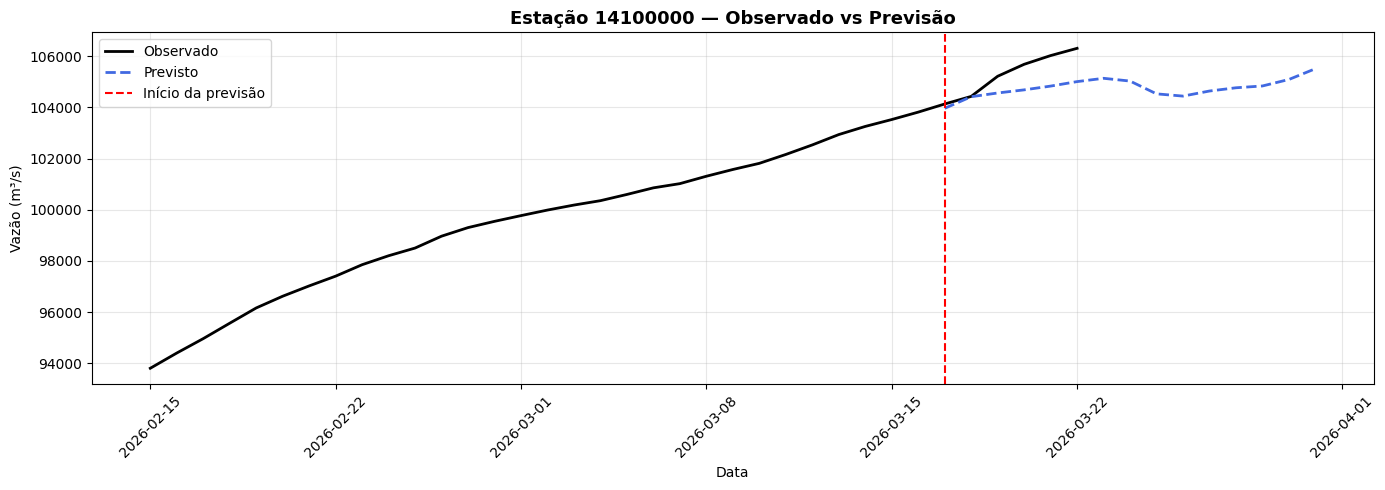

In [15]:
plot_operacional(dados_historicos, previsoes_dict, stations)

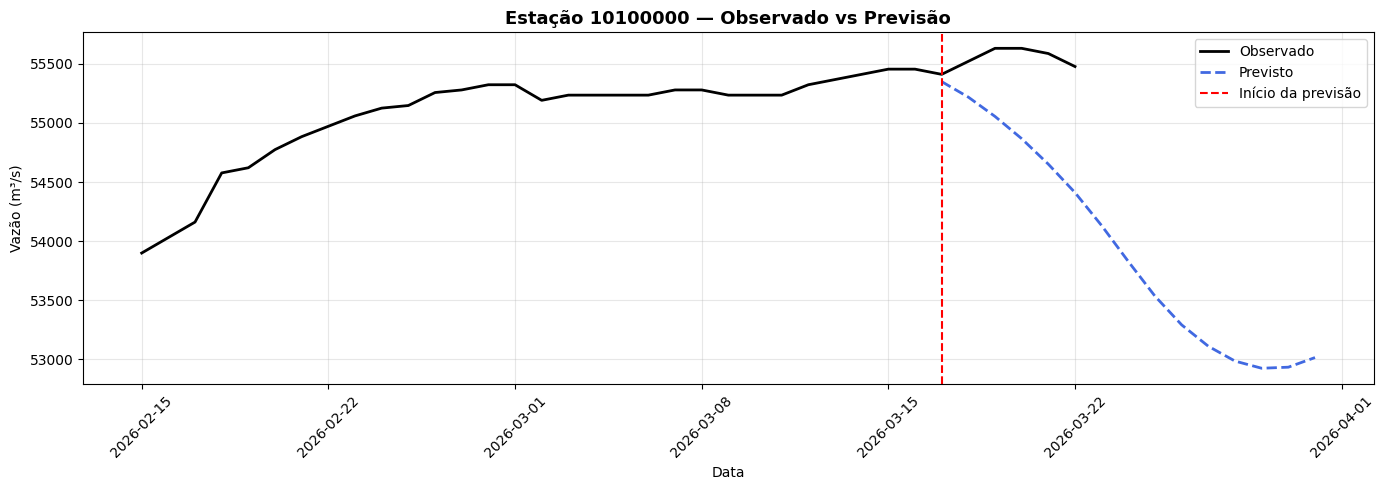

Estação 13050000 sem dados históricos.


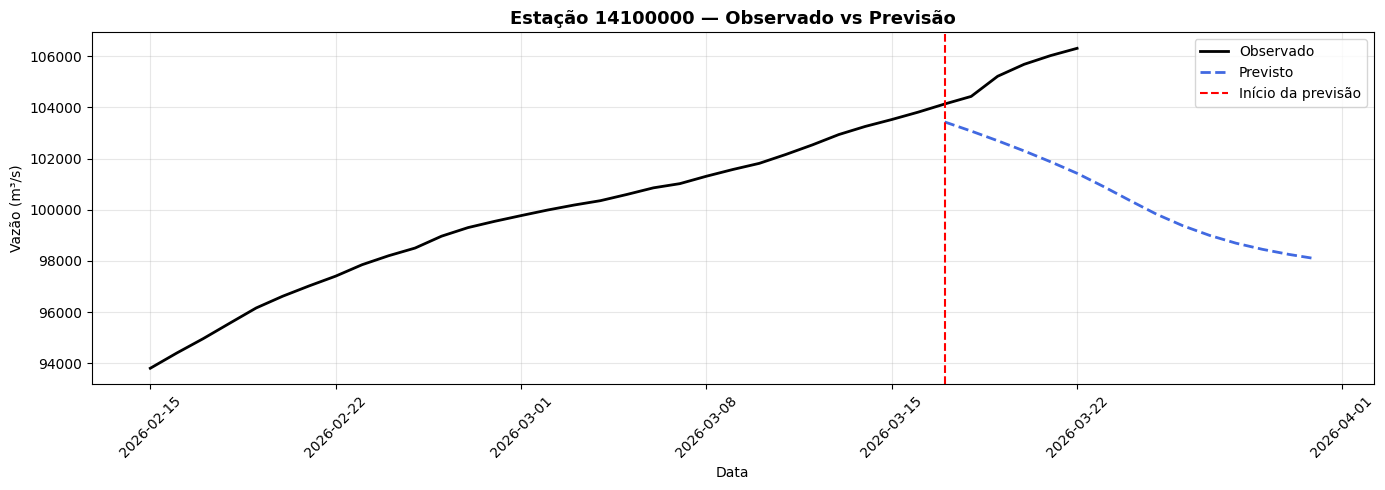

In [20]:
plot_operacional(dados_historicos, previsoes_dict, stations)